# CartPole — Tabular Q-Learning
Balancing a pole on a cart using the Q-Learning algorithm from lecture.

## 1. Imports

In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

## 2. Settings
These are the hyperparameters referenced in the lecture.

In [9]:
num_episodes      = 10_000  # how many games to play during training
learning_rate     = 0.1     # alpha — how fast the agent updates what it learns
discount          = 0.9    # gamma — how much the agent values future rewards
exploration_rate  = 1.0     # epsilon — how often the agent tries random actions
exploration_decay = 0.995   # how quickly exploration slows down over time
min_exploration   = 0.01    # always keep a small amount of exploration
num_buckets       = 20      # how finely we divide each observation into slots

## 3. Discretization
Q-Learning needs a discrete state space, but CartPole gives continuous values.
We divide each observation into buckets — like rounding a temperature to the nearest degree.

In [10]:
# CartPole observation: [cart position, cart speed, pole angle, pole rotation speed]
obs_min = np.array([-2.4, -4.0, -0.2095, -4.0])
obs_max = np.array([ 2.4,  4.0,  0.2095,  4.0])

def get_discrete_state(observation):
    clipped    = np.clip(observation, obs_min, obs_max)
    normalized = (clipped - obs_min) / (obs_max - obs_min)  # scale to 0..1
    bucket_ids = (normalized * num_buckets).astype(int)
    return tuple(np.clip(bucket_ids, 0, num_buckets - 1))

## 4. Q-Table
A lookup table storing how good each action is for every possible state.
Initialized to zero — the agent starts knowing nothing.

In [11]:
# Shape: (20, 20, 20, 20, 2) — 20 buckets per observation, 2 actions (left/right)
q_table = np.zeros([num_buckets] * 4 + [2])

## 5. Training — Algorithm 1: Tabular Q-Learning
Implements the exact algorithm from the lecture notes:

**Update rule:** `Q(s, a) ← Q(s, a) + α [ r + γ · max Q(s') − Q(s, a) ]`

In [12]:
env = gym.make("CartPole-v1")
rewards_per_episode = []

for episode in range(num_episodes):
    raw_observation, _ = env.reset()
    current_state      = get_discrete_state(raw_observation)
    total_reward       = 0
    game_over          = False

    while not game_over:

        # epsilon-greedy: explore randomly or exploit the Q-table
        if np.random.random() < exploration_rate:
            action = env.action_space.sample()          # explore
        else:
            action = np.argmax(q_table[current_state])  # exploit

        # take the action, observe what happens
        new_observation, reward, terminated, truncated, _ = env.step(action)
        game_over  = terminated or truncated
        next_state = get_discrete_state(new_observation)

        # Q-Learning update rule (from lecture, Algorithm 1 line 7):
        # Q(s,a) <- Q(s,a) + alpha * [TD target - current estimate]
        best_future_value = np.max(q_table[next_state])
        current_value     = q_table[current_state][action]
        td_target         = reward + discount * best_future_value * (not game_over)

        q_table[current_state][action] += learning_rate * (td_target - current_value)

        current_state = next_state
        total_reward += reward

    # decay exploration after each episode
    exploration_rate = max(min_exploration, exploration_rate * exploration_decay)
    rewards_per_episode.append(total_reward)

    if (episode + 1) % 1000 == 0:
        recent_avg = np.mean(rewards_per_episode[-1000:])
        print(f"Episode {episode+1:>6} | Avg score (last 1000): {recent_avg:.1f} | Exploration: {exploration_rate:.3f}")

env.close()

Episode   1000 | Avg score (last 1000): 27.9 | Exploration: 0.010
Episode   2000 | Avg score (last 1000): 29.1 | Exploration: 0.010
Episode   3000 | Avg score (last 1000): 30.5 | Exploration: 0.010
Episode   4000 | Avg score (last 1000): 32.1 | Exploration: 0.010
Episode   5000 | Avg score (last 1000): 31.2 | Exploration: 0.010
Episode   6000 | Avg score (last 1000): 31.5 | Exploration: 0.010
Episode   7000 | Avg score (last 1000): 32.1 | Exploration: 0.010
Episode   8000 | Avg score (last 1000): 38.2 | Exploration: 0.010
Episode   9000 | Avg score (last 1000): 56.6 | Exploration: 0.010
Episode  10000 | Avg score (last 1000): 73.0 | Exploration: 0.010


## 6. Training Curve
Plotting the agent's score over time. The moving average shows the learning trend.

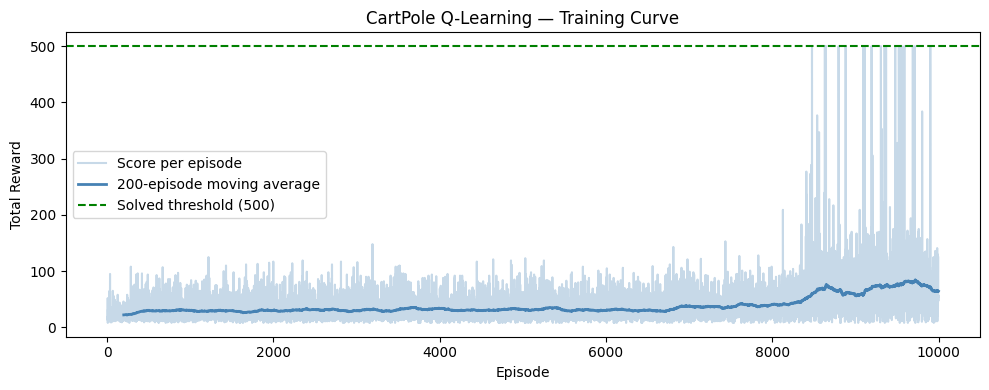

Training curve saved as training_curve.png


In [13]:
window   = 200
smoothed = np.convolve(rewards_per_episode, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(rewards_per_episode, alpha=0.3, color="steelblue", label="Score per episode")
plt.plot(range(window - 1, len(rewards_per_episode)), smoothed, color="steelblue", linewidth=2, label=f"{window}-episode moving average")
plt.axhline(500, color="green", linestyle="--", label="Solved threshold (500)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CartPole Q-Learning — Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()
print("Training curve saved as training_curve.png")

## 7. Evaluation
Test the learned policy with no exploration — pure exploitation of the Q-table.

In [14]:
test_env    = gym.make("CartPole-v1")
test_scores = []

for _ in range(100):
    raw_observation, _ = test_env.reset()
    current_state      = get_discrete_state(raw_observation)
    score              = 0
    game_over          = False

    while not game_over:
        action                                             = np.argmax(q_table[current_state])
        raw_observation, reward, terminated, truncated, _ = test_env.step(action)
        game_over     = terminated or truncated
        current_state = get_discrete_state(raw_observation)
        score        += reward

    test_scores.append(score)

test_env.close()

print(f"Evaluation over 100 episodes:")
print(f"  Average score : {np.mean(test_scores):.1f}")
print(f"  Best score    : {np.max(test_scores):.1f}")
print(f"  Solved (>=475): {'Yes' if np.mean(test_scores) >= 475 else 'Not yet — try more episodes'}")

Evaluation over 100 episodes:
  Average score : 70.7
  Best score    : 161.0
  Solved (>=475): Not yet — try more episodes
